In [1]:
import pandas as pd

In [3]:
train = pd.read_csv("../data/raw/train.csv")
stores = pd.read_csv("../data/raw/stores.csv")
transactions = pd.read_csv("../data/raw/transactions.csv")
oil = pd.read_csv("../data/raw/oil.csv")
holidays = pd.read_csv("../data/raw/holidays_events.csv")


In [4]:
train.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [6]:
train.shape

(3000888, 6)

In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype  
---  ------       -----  
 0   id           int64  
 1   date         object 
 2   store_nbr    int64  
 3   family       object 
 4   sales        float64
 5   onpromotion  int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 137.4+ MB


In [8]:
train.describe()

,id,store_nbr,sales,onpromotion
count,3.000888e+06,3.000888e+06,3.000888e+06,3.000888e+06
mean,1.500444e+06,2.750000e+01,3.577757e+02,2.602770e+00
std,8.662819e+05,1.558579e+01,1.101998e+03,1.221888e+01
min,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
25%,7.502218e+05,1.400000e+01,0.000000e+00,0.000000e+00
50%,1.500444e+06,2.750000e+01,1.100000e+01,0.000000e+00
75%,2.250665e+06,4.100000e+01,1.958473e+02,0.000000e+00
max,3.000887e+06,5.400000e+01,1.247170e+05,7.410000e+02


<Axes: title={'center': 'Total Sales Over Time'}, xlabel='date'>

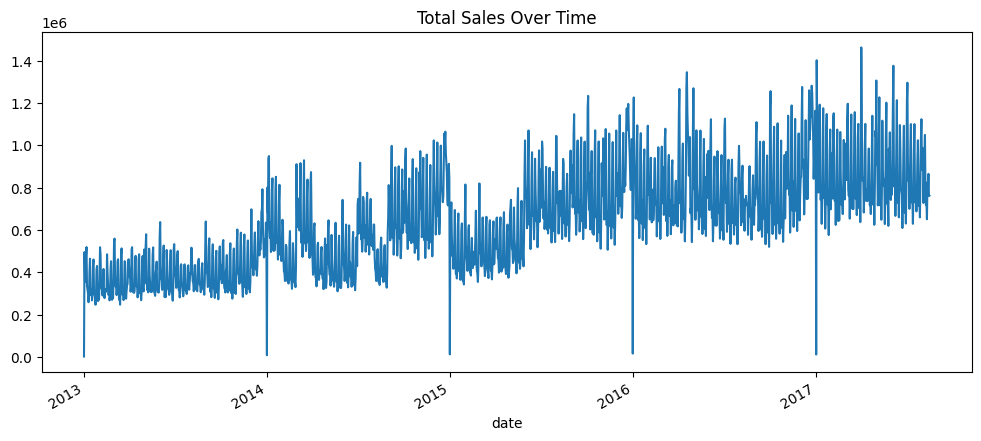

In [9]:
train['date'] = pd.to_datetime(train['date'])

daily_sales = train.groupby('date')['sales'].sum()

daily_sales.plot(figsize=(12,5), title="Total Sales Over Time")

<Axes: title={'center': 'Weekly Seasonality'}, xlabel='day_of_week'>

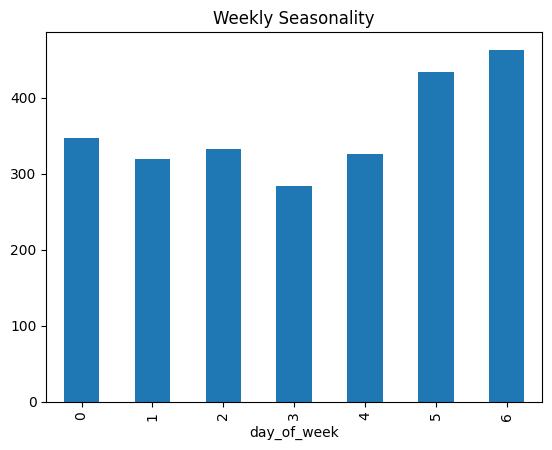

In [10]:
train['day_of_week'] = train['date'].dt.dayofweek

weekly_pattern = train.groupby('day_of_week')['sales'].mean()

weekly_pattern.plot(kind='bar', title="Weekly Seasonality")

In [ ]:
train.isnull().sum()

id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
day_of_week    0
dtype: int64

In [13]:
oil.isnull().sum()

date           0
dcoilwtico    43
dtype: int64

In [14]:
transactions.isnull().sum()

date            0
store_nbr       0
transactions    0
dtype: int64

<Axes: xlabel='store_nbr'>

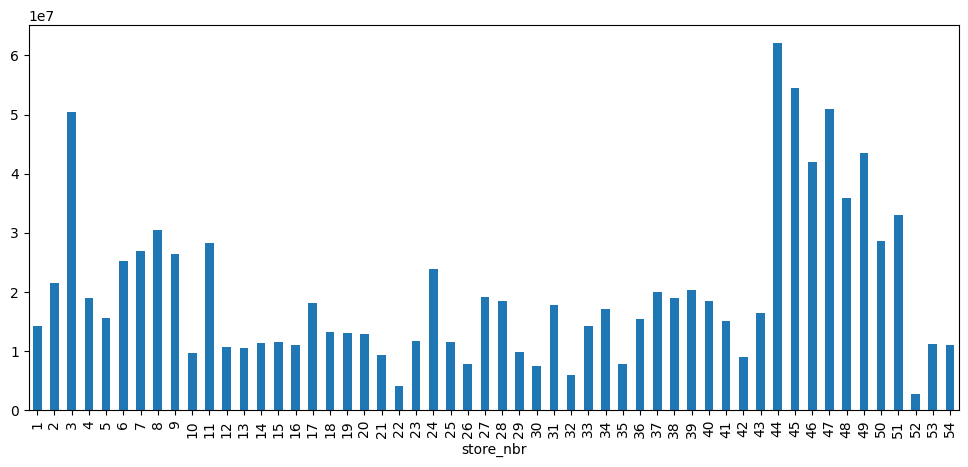

In [16]:
store_sales = train.groupby('store_nbr')['sales'].sum()

store_sales.plot(kind='bar', figsize=(12,5))